# **Bank Customers Churn Prediction**

This project focuses on predicting whether a bank customer is likely to leave (churn) based on their demographic and account-related information. The goal is to help financial institutions proactively identify at-risk customers and take retention measures.

### **Step 01: Importing required libraries**

In [1]:
import pandas as pd  # For data manipulation
import numpy as np # For Numerical work
import matplotlib.pyplot as plt # For visualizations
import seaborn as sns # For Interactive Visualizations

# The warnings module in Python is used to handle warning messages that may arise during code execution.
# Warnings are different from errors—they indicate something that might be a problem or something that could
# lead to unexpected behavior, but they don’t stop the program.
from warnings import filterwarnings
filterwarnings('ignore')

### **Step 02: Loading the Dataset**

In [2]:
df = pd.read_csv('Customer-Churn-Records.csv')

In [3]:
df.head() # Viweing first 5 rows

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


### **Step 03: Exploratory Data Analysis and Data Preprocessing**

In [4]:
df.info() # Overview of the Dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [5]:
df.describe() # Statistical Summary of Numeric Columns

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [6]:
df.isnull().sum() # Checking if any column has null values

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [7]:
df.duplicated().sum() # Checking if we have any duplicate value in our Dataset

np.int64(0)

In [8]:
df['Geography'].value_counts() # Checking how many time each unique value has occured in the given column

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [9]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [10]:
df['Card Type'].value_counts()

,count
Card Type,
DIAMOND,2507
GOLD,2502
SILVER,2496
PLATINUM,2495


In [11]:
df['Exited'].value_counts()

,count
Exited,
0,7962
1,2038


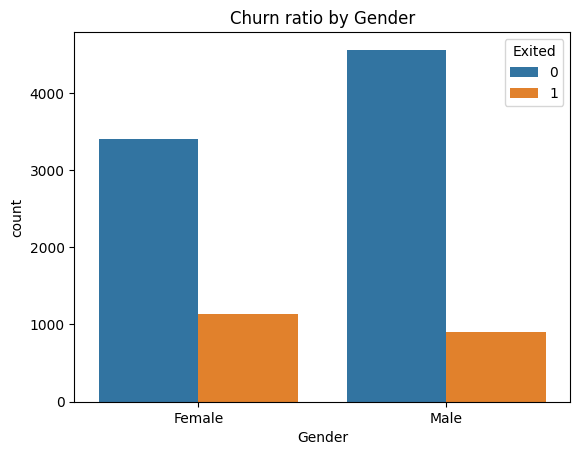

In [12]:
# Plotting a Countplot to see if Gender has any effect on Churn
sns.countplot(x = df['Gender'], data = df, hue = df['Exited'])
plt.title('Churn ratio by Gender')
plt.show()

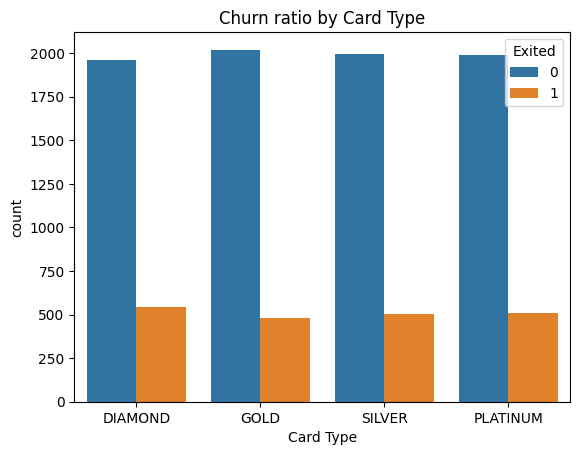

In [13]:
# Plotting a Countplot to see if Card Type has any effect on Churn
sns.countplot(x = df['Card Type'], data = df, hue = df['Exited'])
plt.title('Churn ratio by Card Type')
plt.show()

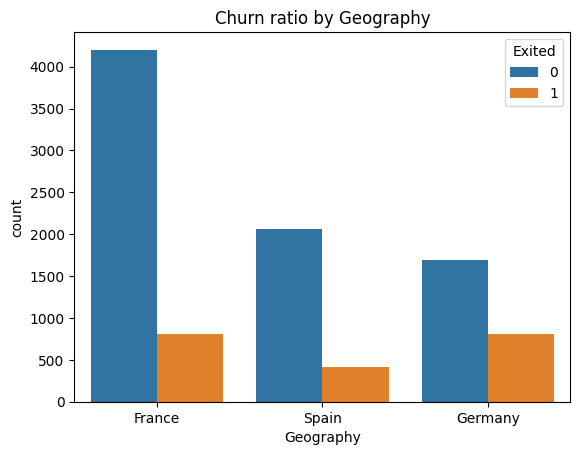

In [14]:
# Plotting a Countplot to see if Geography(country) has any effect on Churn
sns.countplot(x = df['Geography'], data = df, hue = df['Exited'])
plt.title('Churn ratio by Geography')
plt.show()

Text(0.5, 1.0, 'Churn ratio by Age')

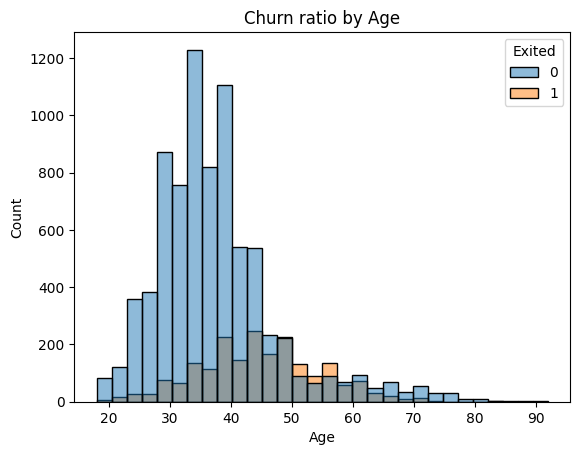

In [15]:
# Plotting a Histogram to check th Age distribution and potential effect on Churn
sns.histplot(x = df['Age'], data = df, hue = df['Exited'], bins = 30)
plt.title('Churn ratio by Age')

In [16]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [17]:
# Let's drop unnecessary columns
df = df.drop(columns = ['RowNumber', 'CustomerId', 'Surname'])

In [18]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [19]:
df = df.rename(columns = {'Geography': 'Country', 'Gender': 'IsFemale'}) # Renaming columns name for convenience

# Replacing categorical values with Numerical Values in IsFemale column.
df['IsFemale'] = df['IsFemale'].apply(lambda x: 1 if x == 'Female' else 0)

In [20]:
X = df.drop('Exited', axis = 1) # X contains all features except Exited
y = df['Exited'] # y contains only Exited feature

In [21]:
X.head()

,CreditScore,Country,IsFemale,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,1,42,2,0.00,1,1,1,101348.88,1,2,DIAMOND,464
1,608,Spain,1,41,1,83807.86,1,0,1,112542.58,1,3,DIAMOND,456
2,502,France,1,42,8,159660.80,3,1,0,113931.57,1,3,DIAMOND,377
3,699,France,1,39,1,0.00,2,0,0,93826.63,0,5,GOLD,350
4,850,Spain,1,43,2,125510.82,1,1,1,79084.10,0,5,GOLD,425


### **Step 04: Feature Encoding**

In [22]:
# Performing One-Hot Encoding on our remaining Categorical features
X = pd.get_dummies(X)

In [23]:
X.head()

,CreditScore,IsFemale,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Point Earned,Country_France,Country_Germany,Country_Spain,Card Type_DIAMOND,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,619,1,42,2,0.00,1,1,1,101348.88,1,2,464,True,False,False,True,False,False,False
1,608,1,41,1,83807.86,1,0,1,112542.58,1,3,456,False,False,True,True,False,False,False
2,502,1,42,8,159660.80,3,1,0,113931.57,1,3,377,True,False,False,True,False,False,False
3,699,1,39,1,0.00,2,0,0,93826.63,0,5,350,True,False,False,False,True,False,False
4,850,1,43,2,125510.82,1,1,1,79084.10,0,5,425,False,False,True,False,True,False,False


In [24]:
X = X.astype('int') # Converting whole X DataFrame to one datatype

### **Step 05: Splitting the Data for Training and testing**

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

### **Step 06: Feature Scaling**

Scaling the features of X_train and X_test

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [27]:
# Scaling he X_train and y_train data values
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **Step 07: Creating Models and Evaluating them**

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score

In [30]:
# Creating Machine Learning Models
models = {
    'LogisticRegression': LogisticRegression(),
    'KNeighborsClassifier': KNeighborsClassifier()
}

In [31]:
for model_name, model in models.items():
    model.fit(X_train_scaled, y_train) # Model Training
    y_pred = model.predict(X_test_scaled) # Model Prediction

    # Evaluation Metrics to evaluate Model Performance
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    confusion = confusion_matrix(y_test, y_pred)

    print(f'Model: {model_name}')
    print(f'Accuracy: {accuracy}')
    print(f'F1 Score: {f1}')
    print(f'Precision: {precision}')
    print(f'Recall: {recall}')
    print(f'Confusion Matrix:\n{confusion}')
    print('-' * 50)

Model: LogisticRegression
Accuracy: 0.999
F1 Score: 0.9974554707379135
Precision: 0.9974554707379135
Recall: 0.9974554707379135
Confusion Matrix:
[[1606    1]
 [   1  392]]
--------------------------------------------------
Model: KNeighborsClassifier
Accuracy: 0.992
F1 Score: 0.9792207792207792
Precision: 1.0
Recall: 0.9592875318066157
Confusion Matrix:
[[1607    0]
 [  16  377]]
--------------------------------------------------


### **Overfitting vs Underfitting**



*   **Overfitting** occurs when our model perform exceptional on training data but fail on testing data. In overfitting, our model try to learn the connection between the features instead of learing the patterns.
*   **Underfitting** occurs when our model perform poorly on both training data as well as testing data. Underfitting happens when our model is too simple to understand the complexity of data and hidden patterns.

In [32]:
# Evaluating if Models are Overfitting or Underfitting
for model_name, model in models.items():
  train_score = model.score(X_train_scaled, y_train)
  test_score = model.score(X_test_scaled, y_test)

  print(f'{model_name} train score: {train_score}')
  print(f'{model_name} test score: {test_score}')
  print('-' * 50)

LogisticRegression train score: 0.9985
LogisticRegression test score: 0.999
--------------------------------------------------
KNeighborsClassifier train score: 0.995
KNeighborsClassifier test score: 0.992
--------------------------------------------------


### **Step 08: Conclusion**

**Logistic Regression**\
Train: 0.9985\
Test: 0.999\
Confusion matrix: only 2 total errors\
👉 This is almost perfect generalization\
👉 The data is almost certainly linearly separable\

**K-Nearest Neighbors**\
Train: 0.995\
Test: 0.992\
Slight drop, but still excellent\
👉 KNN is performing slightly worse, which actually validates our result:\
If both models were identical → suspicious\
Small difference → realistic\

**Final Verdict**\
Almost identical train/test scores
- No overfitting ✅
- No underfitting ✅
- Very stable model ✅

#### **Logistic Regression is better over KNN**